In [181]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder


In [182]:
data_path = Path("./data/loan_cleaned.csv")
df = pd.read_csv(data_path)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [183]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

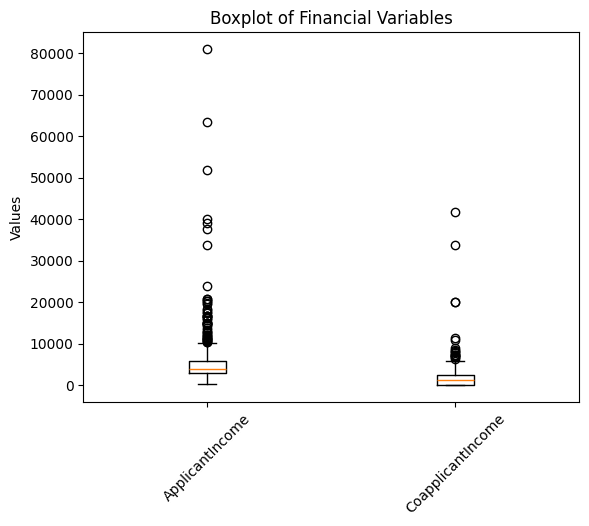

In [184]:
plt.boxplot(df[["ApplicantIncome","CoapplicantIncome"]])
plt.ylabel("Values")
plt.title("Boxplot of Financial Variables")
plt.xticks([1, 2], ["ApplicantIncome", "CoapplicantIncome"], rotation=45)
plt.show()

<Axes: >

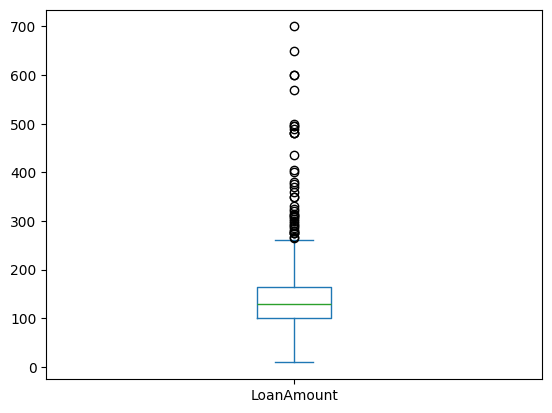

In [185]:
df["LoanAmount"].plot.box()

<Axes: >

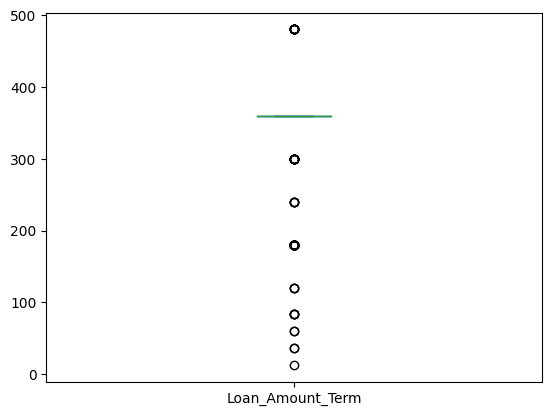

In [186]:
df["Loan_Amount_Term"].plot.box()

In [187]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [188]:
q3_AI =df["ApplicantIncome"].quantile(0.75)
q1_AI =df["ApplicantIncome"].quantile(0.25)
iqr_AI = q3_AI - q1_AI
m = 7
upper_bound_AI = q3_AI + m * iqr_AI
lower_bound_AI = q1_AI - m * iqr_AI

upper_bound_AI, lower_bound_AI

print("Number of outliers in ApplicantIncome:", df[(df["ApplicantIncome"] > upper_bound_AI) | (df["ApplicantIncome"] < lower_bound_AI)]["ApplicantIncome"].count())
df = df[(df["ApplicantIncome"] <= upper_bound_AI) & (df["ApplicantIncome"] >= lower_bound_AI)]

Number of outliers in ApplicantIncome: 7


In [189]:
q3_CI =df["CoapplicantIncome"].quantile(0.75)
q1_CI =df["CoapplicantIncome"].quantile(0.25)
iqr_CI = q3_CI - q1_CI  
m = 3
upper_bound_CI = q3_CI + m * iqr_CI
lower_bound_CI = q1_CI - m * iqr_CI

df[(df["CoapplicantIncome"] > upper_bound_CI) | (df["CoapplicantIncome"] < lower_bound_CI)]["CoapplicantIncome"].count()
df = df[(df["CoapplicantIncome"] <= upper_bound_CI) & (df["CoapplicantIncome"] >= lower_bound_CI)]

In [190]:
df.shape

(601, 13)

In [191]:
# plt.scatter(df["Dependents"], df["Loan_Status"])
# df.scatter(df["Education"], df["Loan_Status"])
df.loc[df["Dependents"] == "3+","Dependents"] = "3"  


df = df.astype({"Dependents": "int64"})
df.info()



<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            601 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            601 non-null    str    
 3   Dependents         601 non-null    int64  
 4   Education          601 non-null    str    
 5   Self_Employed      601 non-null    str    
 6   ApplicantIncome    601 non-null    int64  
 7   CoapplicantIncome  601 non-null    float64
 8   LoanAmount         601 non-null    float64
 9   Loan_Amount_Term   601 non-null    float64
 10  Credit_History     601 non-null    float64
 11  Property_Area      601 non-null    str    
 12  Loan_Status        601 non-null    str    
dtypes: float64(4), int64(2), str(7)
memory usage: 65.7 KB


In [192]:

df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
# df = df.astype({"Loan_Status": "boolean"})
df.info()

<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            601 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            601 non-null    str    
 3   Dependents         601 non-null    int64  
 4   Education          601 non-null    str    
 5   Self_Employed      601 non-null    str    
 6   ApplicantIncome    601 non-null    int64  
 7   CoapplicantIncome  601 non-null    float64
 8   LoanAmount         601 non-null    float64
 9   Loan_Amount_Term   601 non-null    float64
 10  Credit_History     601 non-null    float64
 11  Property_Area      601 non-null    str    
 12  Loan_Status        601 non-null    int64  
dtypes: float64(4), int64(3), str(6)
memory usage: 65.7 KB


In [193]:
df.head()
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
# df["Property_Area"] = df["Property_Area"].map({"Urban": 2, "Semiurban": 1, "Rural": 0})
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            601 non-null    str    
 1   Gender             601 non-null    int64  
 2   Married            601 non-null    int64  
 3   Dependents         601 non-null    int64  
 4   Education          601 non-null    int64  
 5   Self_Employed      601 non-null    int64  
 6   ApplicantIncome    601 non-null    int64  
 7   CoapplicantIncome  601 non-null    float64
 8   LoanAmount         601 non-null    float64
 9   Loan_Amount_Term   601 non-null    float64
 10  Credit_History     601 non-null    float64
 11  Property_Area      601 non-null    str    
 12  Loan_Status        601 non-null    int64  
dtypes: float64(4), int64(7), str(2)
memory usage: 65.7 KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,Urban,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,Rural,0
2,LP001005,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,Urban,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,Urban,1
4,LP001008,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,Urban,1


In [194]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
one_hot_encoder

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [195]:
onehot_encoded_features = one_hot_encoder.fit_transform(df[["Property_Area"]])

onehot_feature_names = one_hot_encoder.get_feature_names_out(["Property_Area"])
onehot_df = pd.DataFrame(onehot_encoded_features, columns=onehot_feature_names,index=df.index)
onehot_df.info()

df.drop("Property_Area", axis=1, inplace=True)
# df = pd.concat([df, onehot_df], axis=1)
df =df.join(onehot_df)
df.drop("Loan_ID", axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property_Area_Rural      601 non-null    float64
 1   Property_Area_Semiurban  601 non-null    float64
 2   Property_Area_Urban      601 non-null    float64
dtypes: float64(3)
memory usage: 18.8 KB
<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   601 non-null    int64  
 1   Married                  601 non-null    int64  
 2   Dependents               601 non-null    int64  
 3   Education                601 non-null    int64  
 4   Self_Employed            601 non-null    int64  
 5   ApplicantIncome          601 non-null    int64  
 6   CoapplicantIncome        601 non-null    float64
 7   LoanAmount           

In [196]:
df.to_csv("./data/loan_preprocessed.csv", index=False)

In [197]:
df.info()

<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   601 non-null    int64  
 1   Married                  601 non-null    int64  
 2   Dependents               601 non-null    int64  
 3   Education                601 non-null    int64  
 4   Self_Employed            601 non-null    int64  
 5   ApplicantIncome          601 non-null    int64  
 6   CoapplicantIncome        601 non-null    float64
 7   LoanAmount               601 non-null    float64
 8   Loan_Amount_Term         601 non-null    float64
 9   Credit_History           601 non-null    float64
 10  Loan_Status              601 non-null    int64  
 11  Property_Area_Rural      601 non-null    float64
 12  Property_Area_Semiurban  601 non-null    float64
 13  Property_Area_Urban      601 non-null    float64
dtypes: float64(7), int64(7)
memory usage: 70.4